# ICP: Aligning Two Point Clouds with SVD

Iterative Closest Point (ICP) answers: given two point clouds that are the same shape but in different positions/orientations, what rotation and translation aligns one onto the other? This notebook implements it from scratch on the Stanford Bunny and shows it recovering a known rigid transform.

## The math

Given two matched point sets $P$ and $Q$ (same length, corresponding points), the rotation $R$ and translation $t$ minimizing $\sum_i \|Rp_i + t - q_i\|^2$ has a closed form (the Kabsch / orthogonal Procrustes solution):

1. Center both sets on their centroids: $\bar p, \bar q$
2. Cross-covariance: $H = \tilde P^T \tilde Q$
3. SVD: $H = U\Sigma V^T$
4. $R = V\,\text{diag}(1,\dots,1,\det(VU^T))\,U^T$ (the $\det$ term fixes a reflection SVD can produce)
5. $t = \bar q - R\bar p$

But real point clouds usually aren't matched point-for-point -- we don't know which point in $Q$ corresponds to which in $P$. ICP works around that by alternating:

1. Guess correspondences: match each point in $P$ to its **nearest neighbor** in $Q$
2. Solve for the best $(R, t)$ given those guessed correspondences
3. Apply it, and repeat until the alignment stops improving

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from linalg_playground.icp import icp, best_rigid_transform

source = np.load("../data/bunny_subsampled.npy")
print("bunny point cloud shape:", source.shape)

bunny point cloud shape: (1889, 3)


In [2]:
theta = np.radians(25)
R_true = np.array([
    [np.cos(theta), -np.sin(theta), 0.0],
    [np.sin(theta), np.cos(theta), 0.0],
    [0.0, 0.0, 1.0],
])
t_true = np.array([0.05, -0.03, 0.02])

target = source @ R_true.T + t_true

In [3]:
aligned, R_est, t_est, errors = icp(source, target, max_iterations=50)
print(f"Converged in {len(errors)} iterations, final mean squared error: {errors[-1]:.2e}")
print("R_est:\n", R_est)
print("R_true:\n", R_true)
print("t_est:", t_est, " t_true:", t_true)

Converged in 20 iterations, final mean squared error: 8.94e-06
R_est:
 [[ 0.92558613 -0.3785027  -0.00510018]
 [ 0.37822962  0.92420752  0.05275233]
 [-0.01525327 -0.05075587  0.9985946 ]]
R_true:
 [[ 0.90630779 -0.42261826  0.        ]
 [ 0.42261826  0.90630779  0.        ]
 [ 0.          0.          1.        ]]
t_est: [ 0.04572209 -0.0329166   0.02353338]  t_true: [ 0.05 -0.03  0.02]


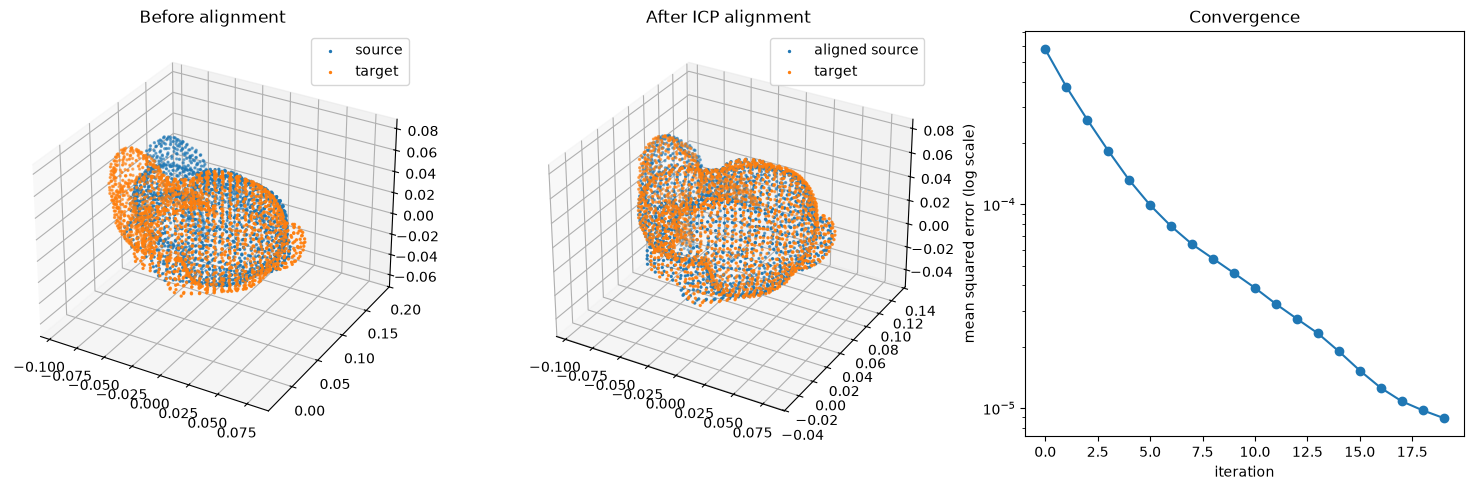

In [4]:
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection="3d")
ax1.scatter(*source.T, s=2, color="tab:blue", label="source")
ax1.scatter(*target.T, s=2, color="tab:orange", label="target")
ax1.set_title("Before alignment")
ax1.legend()

ax2 = fig.add_subplot(132, projection="3d")
ax2.scatter(*aligned.T, s=2, color="tab:blue", label="aligned source")
ax2.scatter(*target.T, s=2, color="tab:orange", label="target")
ax2.set_title("After ICP alignment")
ax2.legend()

ax3 = fig.add_subplot(133)
ax3.plot(errors, marker="o")
ax3.set_yscale("log")
ax3.set_xlabel("iteration")
ax3.set_ylabel("mean squared error (log scale)")
ax3.set_title("Convergence")

plt.tight_layout()
plt.show()

## Takeaway

The same SVD-based "best rotation aligning two point sets" idea from the closed-form Procrustes solution powers the whole iterative loop -- ICP just re-guesses correspondences and re-solves it until the guess stops changing. This is the same rigid-transform math behind real-world point cloud registration in robotics and 3D scanning.